# Tree genera mapping — Demo inference

Minimal example to run inference with the trained Ultralytics YOLO model.

Steps:
1. Check environment (Torch + GPU)
2. Load weights (.pt)
3. Run prediction on one image
4. Visualize detections

Make sure you run this notebook with the project conda kernel.

In [3]:
# Code cell — environment check
import platform
import torch

print("Python:", platform.python_version())
print("Torch :", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: 3.11.4
Torch : 2.2.0
CUDA available: False


In [4]:
# Code cell — load model
from ultralytics import YOLO
from pathlib import Path
from ultralytics import settings

# This updates the global YOLO setting dynamically!
settings.update({"runs_dir": "../cache/runs", "neptune": False})

WEIGHTS = Path("../cache/weights/yolo11l_tree_genus.pt")  # adjust path if needed
assert WEIGHTS.exists(), f"Missing weights: {WEIGHTS}"

model = YOLO(str(WEIGHTS))
print("Loaded:", WEIGHTS)

Loaded: ../cache/weights/yolo11l_tree_genus.pt


In [5]:
# Code cell — choose input image
import rasterio
import numpy as np

IMAGE = Path("../data/samples/sample_r4_c3.tif")  # put a small test image here
assert IMAGE.exists(), f"Missing image: {IMAGE}"

with rasterio.open(IMAGE) as src:
    img_array = src.read()

img_array = np.transpose(img_array,(1,2,0))
img_array.shape

(640, 640, 5)

In [6]:
# Code cell — run prediction
device = 0 if torch.cuda.is_available() else "cpu"

results = model.predict(
    source=img_array,
    device=device,
    conf=0.25,
    imgsz=640,
    # save=True,
    # project="predictions",  # The main folder
    # name=IMAGE.stem
)



0: 640x640 43 Acers, 15 Aesculuss, 5 Coniferouss, 15 Other Deciduouss, 6 Quercuss, 9 Tilias, 223.2ms
Speed: 4.9ms preprocess, 223.2ms inference, 3.8ms postprocess per image at shape (1, 5, 640, 640)


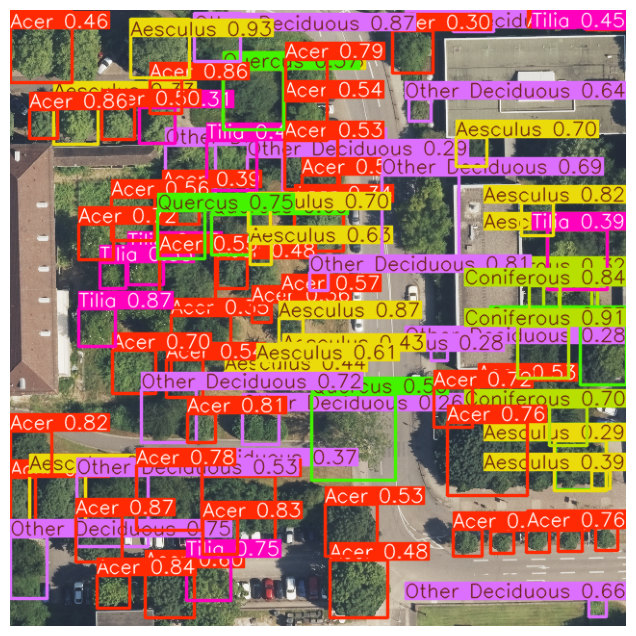

In [7]:
# Code cell — visualize
import matplotlib.pyplot as plt
import cv2

img_bgr = results[0].plot()[..., ::-1]
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,8))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

In [8]:
# Code cell — export boxes
import pandas as pd

r = results[0]
boxes = r.boxes

df = pd.DataFrame({
    "x1": boxes.xyxy[:,0].cpu(),
    "y1": boxes.xyxy[:,1].cpu(),
    "x2": boxes.xyxy[:,2].cpu(),
    "y2": boxes.xyxy[:,3].cpu(),
    "conf": boxes.conf.cpu(),
    "cls": boxes.cls.cpu().int()
})

df.head()

,x1,y1,x2,y2,conf,cls
0,125.648628,9.089369,186.707092,70.506668,0.932154,1
1,527.284912,328.766327,580.232544,382.592560,0.913295,3
2,279.563171,320.387817,304.691345,346.019470,0.873177,1
3,68.482391,525.072754,116.456619,573.513184,0.872045,0
4,191.055191,3.971237,239.573135,53.419655,0.869079,5
